Frame de máximo enfoque (Todo el frame): 111
Frame de máximo enfoque (ROI 10%): 111


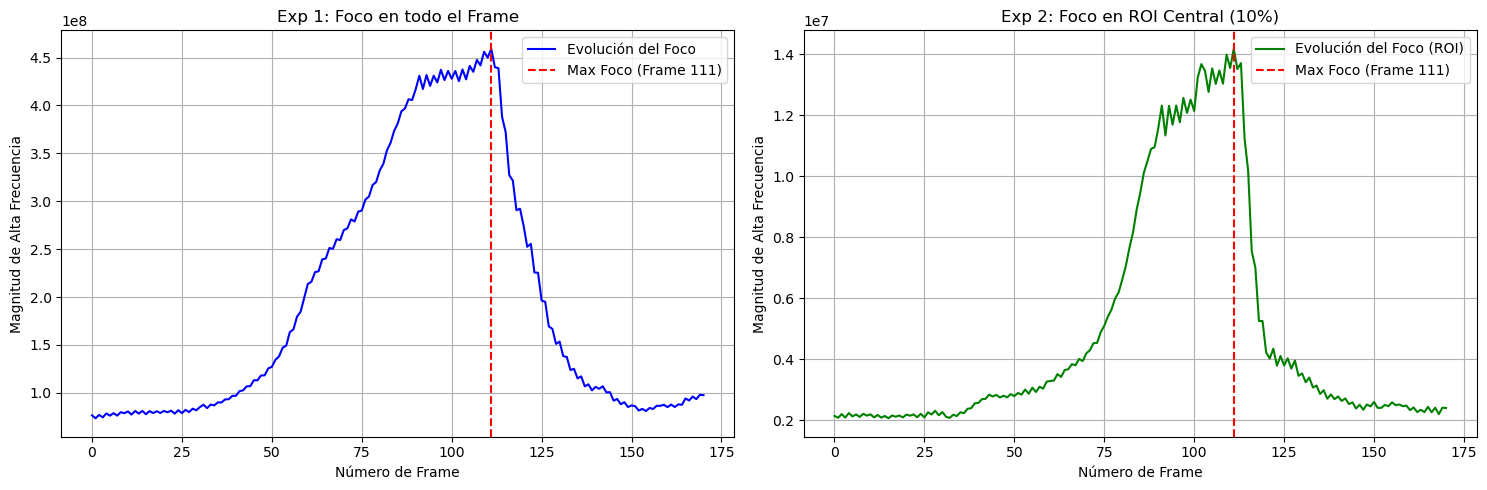

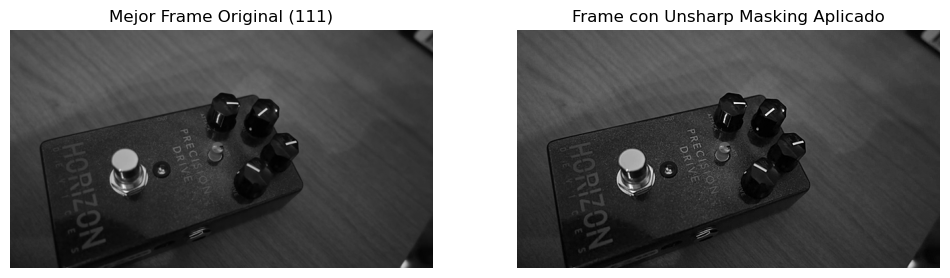

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def image_sharpness_measure_fft(image):
    # Transformamos la imagen al dominio de frecuencia espacial usando FFT
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    
    # Obtenemos el espectro de magnitud
    magnitude_spectrum = np.abs(fshift)
    
    # Detectamos y filtramos las componentes de baja frecuencia (centro)
    # dejando solo las altas frecuencias (los bordes)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    r = 30 # Radio para el enmascaramiento de bajas frecuencias
    
    # Anulamos el centro (bajas frecuencias)
    magnitude_spectrum[crow-r:crow+r, ccol-r:ccol+r] = 0
    
    # La métrica será la sumatoria de las componentes de alta frecuencia restantes
    sharpness_metric = np.sum(magnitude_spectrum)
    
    return sharpness_metric

def apply_unsharp_masking(image, k=1.0):
    # Desenfoque de la imagen con un filtro suavizador Gaussiano
    f_b = cv2.GaussianBlur(image, (5, 5), 1.0)
    
    # float64 ayuda a evitar desbordamientos
    img_float = image.astype(np.float64)
    f_b_float = f_b.astype(np.float64)
    
    # Resta de la imagen original con la suavizada (máscara)
    m = img_float - f_b_float
    
    # Agregar esa máscara a la imagen original (k=1 para Unsharp Masking)
    g = img_float + (k * m)
    
    # Acotamos los valores a 0-255 y volvemos a uint8
    g = np.clip(g, 0, 255).astype(np.uint8)
    
    return g

def process_video_and_plot(video_path):
    # Inicializamos la captura de video
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: No se pudo abrir el video {video_path}")
        return
    
    # Listas para almacenar las métricas frame a frame
    metrics_full = []
    metrics_roi = []
    frames_list = [] # Guardaremos copias para extraer los frames enfocados más tarde
    
    frame_idx = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Conversión a escala de grises para el análisis de frecuencia
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames_list.append(frame.copy())
        
        # Experimento 1 - Medición sobre todo el frame
        metric_full = image_sharpness_measure_fft(gray)
        metrics_full.append(metric_full)
        
        # Experimento 2 - Medición sobre ROI (10% del área total)
        rows, cols = gray.shape
        area_total = rows * cols
        area_roi = area_total * 0.10
        
        # Cálculo de dimensiones del ROI asumiendo proporción cuadrada para simplificar
        roi_side = int(np.sqrt(area_roi))
        r_start = (rows - roi_side) // 2
        r_end = r_start + roi_side
        c_start = (cols - roi_side) // 2
        c_end = c_start + roi_side
        
        roi = gray[r_start:r_end, c_start:c_end]
        metric_roi = image_sharpness_measure_fft(roi)
        metrics_roi.append(metric_roi)
        
        frame_idx += 1
        
    cap.release()
    
    # Detección automática del punto de máximo enfoque
    max_focus_idx_full = np.argmax(metrics_full)
    max_focus_idx_roi = np.argmax(metrics_roi)
    
    print(f"Frame de máximo enfoque (Todo el frame): {max_focus_idx_full}")
    print(f"Frame de máximo enfoque (ROI 10%): {max_focus_idx_roi}")
    
    # Gráficos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Curva Experimento 1
    ax1.plot(metrics_full, label='Evolución del Foco', color='b')
    ax1.axvline(x=max_focus_idx_full, color='r', linestyle='--', label=f'Max Foco (Frame {max_focus_idx_full})')
    ax1.set_title('Exp 1: Foco en todo el Frame')
    ax1.set_xlabel('Número de Frame')
    ax1.set_ylabel('Magnitud de Alta Frecuencia')
    ax1.legend()
    ax1.grid(True)
    
    # Curva Experimento 2
    ax2.plot(metrics_roi, label='Evolución del Foco (ROI)', color='g')
    ax2.axvline(x=max_focus_idx_roi, color='r', linestyle='--', label=f'Max Foco (Frame {max_focus_idx_roi})')
    ax2.set_title('Exp 2: Foco en ROI Central (10%)')
    ax2.set_xlabel('Número de Frame')
    ax2.set_ylabel('Magnitud de Alta Frecuencia')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Puntos Extra - Extraer mejor frame (según el método completo) y aplicar unsharp masking
    best_frame_bgr = frames_list[max_focus_idx_full]
    best_frame_gray = cv2.cvtColor(best_frame_bgr, cv2.COLOR_BGR2GRAY)
    enhanced_frame = apply_unsharp_masking(best_frame_gray, k=1.0)
    
    # Resultados del Unsharp Masking
    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 6))
    ax3.imshow(best_frame_gray, cmap='gray')
    ax3.set_title(f"Mejor Frame Original ({max_focus_idx_full})")
    ax3.axis('off')
    
    ax4.imshow(enhanced_frame, cmap='gray')
    ax4.set_title("Frame con Unsharp Masking Aplicado")
    ax4.axis('off')
    plt.show()

process_video_and_plot('focus_video.mov')

Algoritmo FFT - Primero, se aplica una Transformada Rápida de Fourier 2D (np.fft.fft2) para pasar la imagen del dominio espacial al dominio frecuencial. Se centra el espectro (fftshift) para que las frecuencias bajas (los cambios suaves de iluminación y colores planos) queden en el centro geométrico de la matriz, y las frecuencias altas (los bordes nítidos, texturas finas y ruido) queden en la periferia. Dado que el enfoque afecta principalmente a los bordes, bloqueamos, poniendo a 0, un radio central correspondiente a las bajas frecuencias. 

La suma total de la magnitud espectral restante nos entrega un escalar: a mayor valor, más componentes de alta frecuencia hay, lo que significa que la imagen está más nítida/enfocada. 

Experimento 1 - Medición sobre todo el frame: Se pasa la imagen completa (en escala de grises) por el algoritmo métrico para cada cuadro. En la curva generada por el script, los valles representan cuadros borrosos y los picos representan cuadros nítidos. El punto máximo absoluto (marcado con la línea roja) detecta cuándo toda la escena alcanzó su máxima nitidez general.

Experimento 2 - ROI central: Se recorta geométricamente un cuadrado o rectángulo exacto en el centro de la imagen. Al pedir un área del 10% ($Area_{roi} = 0.10 \times Area_{total}$), la anchura y altura de la ROI se calculan multiplicando las dimensiones originales por la $\sqrt{0.10}$ (aprox 0.316). La curva de este experimento suele ser mucho más pronunciada y precisa respecto al objeto de interés (asumiendo que el sujeto principal está en el centro, como ocurre en la mayoría de los sistemas de autoenfoque de cámaras). Al ignorar los bordes periféricos de la imagen, la métrica no se contamina por texturas de fondo (como árboles o paredes) y aísla el enfoque en el objetivo principal. El pico máximo de esta curva representa el punto ideal de enfoque fotográfico.